# 03 Stress Tests

## Why This Notebook Exists
This notebook evaluates tail behavior using both realized historical windows and synthetic Monte Carlo paths. It focuses on drawdown behavior, recovery, and return distribution asymmetry.

## Stress Modes Covered
- Historical windows from `stress.scenarios` in YAML (real events).
- Monte Carlo paths from `stress.monte_carlo` (permutation or block bootstrap).


In [9]:
# Standard notebook bootstrap.
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from src.experiments.run_baseline import run as run_baseline
from src.experiments.run_stress import run as run_stress
from src.utils.io import load_config


## Controls
- Use `default.yaml` for both pairs, or a pair-specific config for faster runs.
- Monte Carlo runtime scales with `n_paths x horizon_days`; reduce these for quick iteration.


In [10]:
CONFIG_PATH = ROOT / "configs" / "default.yaml"
cfg = load_config(CONFIG_PATH)

# Baseline is required because historical stress slices are taken from realized strategy path.
backtests = run_baseline(str(CONFIG_PATH))
stress = run_stress(str(CONFIG_PATH)).sort_values(["pair", "scenario"]).reset_index(drop=True)
stress


,pair,scenario,start,end,trading_days,window_return,max_drawdown,recovery_days,avg_gross,avg_turnover,rebalance_count,scheduled_rebalance_count,threshold_rebalance_count,spot_pnl_total,lev_pnl_total,raw_pnl_total,cost_total,net_pnl_total
0,btc_bitx,crypto_vol_spike_2024,2024-03-01,2024-06-30,122,0.061536,-0.061226,78.0,0.996214,0.018246,39,18,23,0.045276,0.028432,0.073709,0.003985,0.069724
1,qqq_tqqq,growth_selloff_2022,2022-01-01,2022-10-31,216,0.005152,-0.003045,76.0,1.001849,0.017084,87,31,62,-0.232086,0.244804,0.012718,0.007558,0.005160


## Historical Scenario Diagnostics
- `window_return`: compounded strategy return over the scenario window.
- `max_drawdown`: worst peak-to-trough within that window.
- `recovery_days`: days needed to recover previous peak (if recovered).
- `threshold_rebalance_count`: count of threshold-triggered rebalances in window.


In [11]:
for pair_name, group in stress.groupby("pair"):
    print(f"\n{pair_name}")
    display(group[[
        "scenario",
        "start",
        "end",
        "window_return",
        "max_drawdown",
        "recovery_days",
        "avg_gross",
        "threshold_rebalance_count",
    ]])



btc_bitx


,scenario,start,end,window_return,max_drawdown,recovery_days,avg_gross,threshold_rebalance_count
0,crypto_vol_spike_2024,2024-03-01,2024-06-30,0.061536,-0.061226,78.0,0.996214,23



qqq_tqqq


,scenario,start,end,window_return,max_drawdown,recovery_days,avg_gross,threshold_rebalance_count
1,growth_selloff_2022,2022-01-01,2022-10-31,0.005152,-0.003045,76.0,1.001849,62


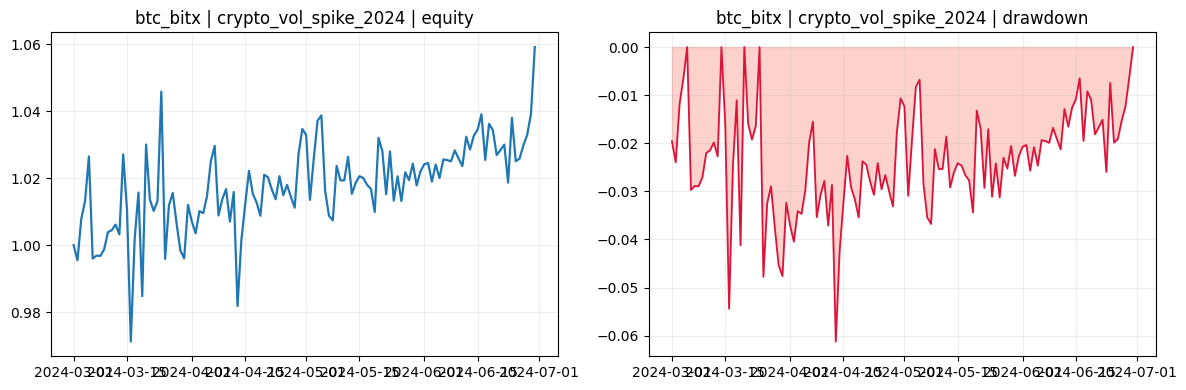

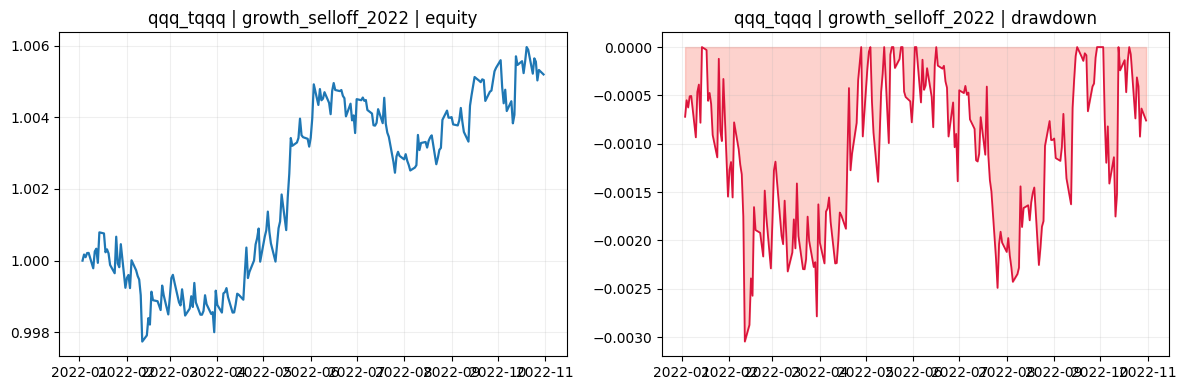

In [12]:
# Plot scenario-level equity and drawdown traces.
for _, row in stress.iterrows():
    pair = row["pair"]
    start = pd.Timestamp(row["start"], tz="UTC")
    end = pd.Timestamp(row["end"], tz="UTC")

    bt = backtests[pair]
    window = bt.loc[(bt.index >= start) & (bt.index <= end)].copy()
    if window.empty:
        continue

    # Normalize to 1.0 for apples-to-apples shape comparison across windows.
    window["equity_norm"] = window["equity"] / window["equity"].iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(window.index, window["equity_norm"], lw=1.6)
    axes[0].set_title(f"{pair} | {row['scenario']} | equity")
    axes[0].grid(alpha=0.2)

    axes[1].plot(window.index, window["drawdown"], color="crimson", lw=1.3)
    axes[1].fill_between(window.index, window["drawdown"], 0, color="salmon", alpha=0.35)
    axes[1].set_title(f"{pair} | {row['scenario']} | drawdown")
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


In [13]:
# Basic PnL attribution inside each stress window.
attrib_rows = []
for _, row in stress.iterrows():
    pair = row["pair"]
    bt = backtests[pair]
    start = pd.Timestamp(row["start"], tz="UTC")
    end = pd.Timestamp(row["end"], tz="UTC")
    window = bt.loc[(bt.index >= start) & (bt.index <= end)]
    if window.empty:
        continue

    attrib_rows.append({
        "pair": pair,
        "scenario": row["scenario"],
        "spot_pnl_mean": window["spot_pnl"].mean(),
        "lev_pnl_mean": window["lev_pnl"].mean(),
        "cost_total_mean": window["cost_total"].mean(),
    })

pd.DataFrame(attrib_rows).sort_values(["pair", "scenario"]).reset_index(drop=True)


,pair,scenario,spot_pnl_mean,lev_pnl_mean,cost_total_mean
0,btc_bitx,crypto_vol_spike_2024,0.000371,0.000233,0.000033
1,qqq_tqqq,growth_selloff_2022,-0.001074,0.001133,0.000035


## Monte Carlo Diagnostics
- `stress_monte_carlo_summary.csv` contains return quantiles and tail-loss probabilities.
- `*_mc_path_metrics.csv` contains per-path metrics (total return, max drawdown, recovery).
- Fan charts are written to `reports/figures/*_mc_equity_fan.png`.


In [14]:
mc_summary_path = ROOT / "reports" / "tables" / "stress_monte_carlo_summary.csv"
if mc_summary_path.exists():
    mc_summary = pd.read_csv(mc_summary_path).sort_values("pair")
    mc_summary
else:
    print("Monte Carlo summary not found yet. Run stress once from CLI or this notebook.")


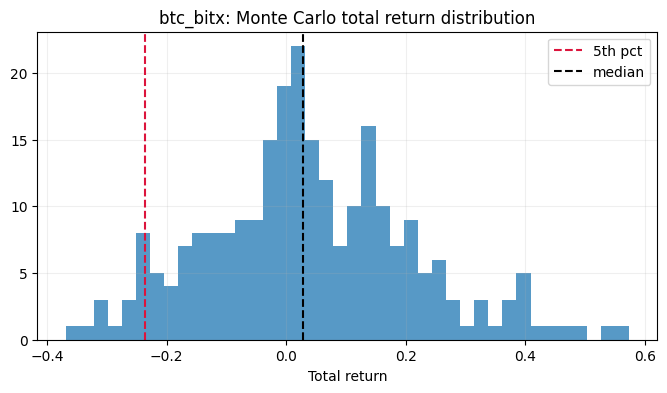

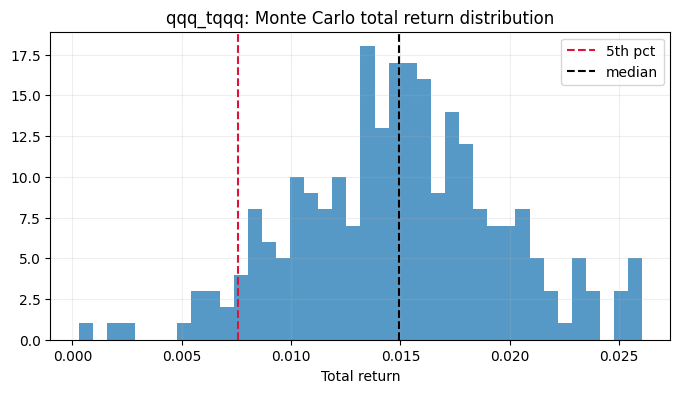

In [15]:
# Distribution plots for total return across simulated paths.
for pair in ["btc_bitx", "qqq_tqqq"]:
    path_file = ROOT / "reports" / "tables" / f"{pair}_mc_path_metrics.csv"
    if not path_file.exists():
        print(f"Missing path metrics: {path_file}")
        continue

    df = pd.read_csv(path_file)
    if df.empty:
        print(f"Empty path metrics for {pair}")
        continue

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df["total_return"], bins=40, alpha=0.75)
    ax.axvline(df["total_return"].quantile(0.05), color="crimson", ls="--", label="5th pct")
    ax.axvline(df["total_return"].quantile(0.50), color="black", ls="--", label="median")
    ax.set_title(f"{pair}: Monte Carlo total return distribution")
    ax.set_xlabel("Total return")
    ax.grid(alpha=0.2)
    ax.legend()
    plt.show()


In [16]:
# Minimal integrity checks.
assert not stress.empty, "Stress scenarios table is empty"
assert (stress["max_drawdown"] <= 0).all(), "max_drawdown should be <= 0"
print("Stress checks passed.")


Stress checks passed.


## Next Notebook
Use `04_results_figures.ipynb` to export a concise, presentation-ready figure/table pack from the latest run.
